# FinBERT Sentiment Analysis on 10-Q MD&A Sections

**Pipeline overview**

1. Synthetic dataset — 200 sentences from 10-Q MD&A reports (10 tickers, 12 quarters)
2. Time-based **stratified** train/test split (train = older quarters → test = newer quarters)
3. Fine-tune **FinBERT** (`ProsusAI/finbert`) for 3-class sentiment
4. Evaluate: Precision · Recall · F1 (Macro & Weighted) · Confusion Matrix
5. Baseline comparison: **Loughran-McDonald dictionary + Linear SVM**


In [ ]:
import numpy as np
import pandas as pd
import random
from datetime import date
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 110

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset as HFDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"Device   : {DEVICE}")


PyTorch  : 2.10.0
CUDA     : False
Device   : cpu


## 1. Synthetic Dataset


In [ ]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "NVDA", "JPM", "BAC", "GS"]

QUARTER_DATES = {
    ("2021", "Q1"): date(2021, 3, 31),
    ("2021", "Q2"): date(2021, 6, 30),
    ("2021", "Q3"): date(2021, 9, 30),
    ("2021", "Q4"): date(2021, 12, 31),
    ("2022", "Q1"): date(2022, 3, 31),
    ("2022", "Q2"): date(2022, 6, 30),
    ("2022", "Q3"): date(2022, 9, 30),
    ("2022", "Q4"): date(2022, 12, 31),
    ("2023", "Q1"): date(2023, 3, 31),
    ("2023", "Q2"): date(2023, 6, 30),
    ("2023", "Q3"): date(2023, 9, 30),
    ("2023", "Q4"): date(2023, 12, 31),
}

POSITIVE_SENTENCES = [
    "Revenue increased {pct}% year-over-year driven by strong demand across our core product lines.",
    "Gross profit margin expanded by {bp} basis points reflecting improved operational efficiency.",
    "Net income grew {pct}% compared to the prior year period exceeding analyst expectations.",
    "We delivered record quarterly revenue of ${amt} billion a new high for the company.",
    "Customer acquisition accelerated with active users growing {pct}% year-over-year.",
    "Our cloud segment outperformed posting {pct}% revenue growth in the quarter.",
    "Operating cash flow increased to ${amt} billion demonstrating the strength of our business model.",
    "We successfully launched new products that have been well received by customers.",
    "International expansion drove {pct}% growth in revenue outside our domestic markets.",
    "Return on equity improved to {pct}% reflecting disciplined capital allocation.",
    "The integration of our recent acquisition is progressing ahead of schedule and on budget.",
    "We raised our full-year guidance reflecting confidence in the strength of our business.",
    "Our balance sheet remains strong with ${amt} billion in cash and liquid investments.",
    "Loan originations increased {pct}% driven by robust consumer and commercial demand.",
    "Net interest margin expanded as we benefited from the rising rate environment.",
    "Earnings per share of ${amt} exceeded consensus estimates by a wide margin.",
    "Our subscription revenue reached an all-time high growing {pct}% quarter-over-quarter.",
    "We returned ${amt} billion to shareholders through dividends and share repurchases.",
    "Cost reduction program completion contributed meaningfully to margin improvement.",
    "Our market share expanded reflecting the competitive strength of our products.",
    "Digital channel adoption increased {pct}% significantly improving customer engagement.",
    "Productivity improvements led to a {pct}% reduction in unit costs.",
    "New contract wins totaling ${amt} billion represent a strong future revenue foundation.",
    "Credit quality remained excellent with non-performing assets at historically low levels.",
    "Technology investments are yielding strong returns improving customer satisfaction.",
]

NEUTRAL_SENTENCES = [
    "The company operates in three reportable segments: consumer, enterprise, and government.",
    "Capital expenditures for the quarter totaled ${amt} billion consistent with annual guidance.",
    "We had approximately {cnt} full-time employees as of the end of the quarter.",
    "The Board of Directors declared a quarterly dividend of ${amt} per share.",
    "Our effective tax rate for the quarter was {pct}% consistent with prior periods.",
    "We are subject to various legal proceedings in the normal course of business.",
    "Depreciation and amortization expense was ${amt} million for the three months ended.",
    "The company maintains credit facilities totaling ${amt} billion with financial institutions.",
    "Our fiscal year ends on December 31 and we report on a calendar quarter basis.",
    "Inventory levels at quarter end were ${amt} billion reflecting seasonal demand patterns.",
    "We file our 10-Q and 10-K reports with the Securities and Exchange Commission.",
    "The company conducts business in over {cnt} countries across all major geographic regions.",
    "Research and development expenses were ${amt} million representing {pct}% of net revenues.",
    "Total assets as of quarter end were ${amt} billion compared to prior year end.",
    "The weighted-average diluted shares outstanding for the quarter were {cnt} million.",
    "We have operating leases for office space, data centers, and retail locations.",
    "Our principal executive offices are located at our corporate headquarters.",
    "We recognize revenue in accordance with ASC 606 Revenue from Contracts with Customers.",
    "The company uses derivative instruments to hedge foreign currency and interest rate risk.",
    "Goodwill and intangible assets totaled ${amt} billion following our acquisition activities.",
    "Common stock repurchases under our authorized program totaled ${amt} billion for the quarter.",
    "The preparation of financial statements requires management to make estimates and assumptions.",
    "We manage our business across the Americas, EMEA, and Asia Pacific regions.",
    "Long-term debt outstanding was ${amt} billion as of the end of the quarter.",
    "Our audit committee met {cnt} times during the quarter to review financial controls.",
]

NEGATIVE_SENTENCES = [
    "Operating expenses increased {pct}% driven by higher headcount and infrastructure costs.",
    "We experienced supply chain disruptions that negatively impacted our production capacity.",
    "Revenue declined {pct}% year-over-year due to reduced consumer spending and market headwinds.",
    "Gross margin contracted by {bp} basis points primarily due to inflationary cost pressures.",
    "Net loss for the quarter was ${amt} million reflecting challenging macroeconomic conditions.",
    "We are facing increased competition that has resulted in pricing pressure across key markets.",
    "Inventory write-downs of ${amt} million were recorded due to slower-than-expected demand.",
    "Credit losses increased to ${amt} million reflecting deterioration in the macro environment.",
    "Foreign exchange headwinds negatively impacted revenue by approximately {pct}%.",
    "We recorded an impairment charge of ${amt} billion related to our goodwill assessment.",
    "Customer churn increased during the quarter negatively impacting our recurring revenue base.",
    "Rising interest rates have increased borrowing costs and reduced demand for our products.",
    "We are subject to regulatory investigations that may result in significant fines or penalties.",
    "Restructuring charges of ${amt} million were recognized in connection with our cost reduction program.",
    "Operating cash flow declined {pct}% due to higher working capital requirements.",
    "Loan delinquencies increased {pct}% compared to the prior quarter reflecting economic stress.",
    "Advertising revenue declined significantly as marketers reduced spending amid uncertainty.",
    "We identified material weaknesses in our internal controls over financial reporting.",
    "Increased competition from new entrants has put pressure on our margins.",
    "The company expects revenue next quarter to be below consensus analyst estimates.",
    "Litigation expenses increased materially due to ongoing legal proceedings and settlements.",
    "We are experiencing higher attrition rates which have increased talent acquisition costs.",
    "Commodity price increases have significantly impacted our cost of goods sold.",
    "Non-performing loans increased to {pct}% of total loans above our historical average.",
    "Our backlog declined {pct}% quarter-over-quarter signaling weaker near-term demand.",
]

print(
    f"Sentence pools — positive: {len(POSITIVE_SENTENCES)}, neutral: {len(NEUTRAL_SENTENCES)}, negative: {len(NEGATIVE_SENTENCES)}"
)


Sentence pools — positive: 25, neutral: 25, negative: 25


In [ ]:
def fill_template(tmpl):
    return (
        tmpl.replace("{pct}", str(random.randint(5, 35)))
        .replace("{bp}", str(random.randint(50, 300)))
        .replace("{amt}", str(round(random.uniform(0.5, 15.0), 1)))
        .replace("{cnt}", str(random.randint(10, 500)))
    )


LABEL_POOLS = {
    "positive": POSITIVE_SENTENCES,
    "neutral": NEUTRAL_SENTENCES,
    "negative": NEGATIVE_SENTENCES,
}
LABEL_COUNTS = {"positive": 67, "neutral": 67, "negative": 66}  # total = 200
quarters = list(QUARTER_DATES.keys())

rows = []
for label, count in LABEL_COUNTS.items():
    for _ in range(count):
        ticker = random.choice(TICKERS)
        year, qtr = random.choice(quarters)
        qdate = QUARTER_DATES[(year, qtr)]
        text = fill_template(random.choice(LABEL_POOLS[label]))
        rows.append(
            {
                "ticker": ticker,
                "year": year,
                "quarter": qtr,
                "date": qdate,
                "processed_text": text,
                "sentiment_label": label,
            }
        )

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Dates  : {df['date'].min().date()} → {df['date'].max().date()}")
print()
print(df["sentiment_label"].value_counts())
df.head(8)


Shape  : (200, 6)
Columns: ['ticker', 'year', 'quarter', 'date', 'processed_text', 'sentiment_label']
Dates  : 2021-03-31 → 2023-12-31

sentiment_label
positive    67
neutral     67
negative    66
Name: count, dtype: int64


,ticker,year,quarter,date,processed_text,sentiment_label
0,MSFT,2021,Q1,2021-03-31,Credit quality remained excellent with non-per...,positive
1,JPM,2021,Q1,2021-03-31,Increased competition from new entrants has pu...,negative
2,JPM,2021,Q1,2021-03-31,The company conducts business in over 466 coun...,neutral
3,META,2021,Q1,2021-03-31,Net income grew 25% compared to the prior year...,positive
4,AAPL,2021,Q1,2021-03-31,We identified material weaknesses in our inter...,negative
5,MSFT,2021,Q1,2021-03-31,Net interest margin expanded as we benefited f...,positive
6,GS,2021,Q1,2021-03-31,Our market share expanded reflecting the compe...,positive
7,MSFT,2021,Q1,2021-03-31,Digital channel adoption increased 22% signifi...,positive


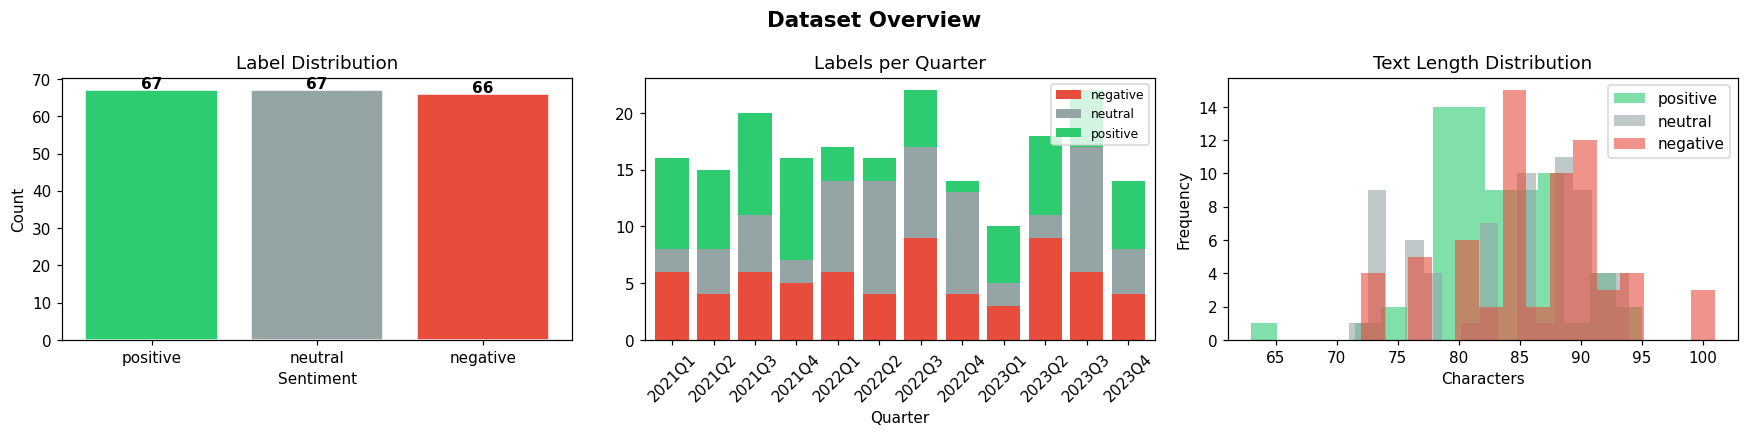

count    200.0
mean      84.4
std        6.2
min       63.0
25%       81.0
50%       85.0
75%       89.0
max      101.0
Name: text_len, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

vc = df["sentiment_label"].value_counts()
palette = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

axes[0].bar(
    vc.index, vc.values, color=[palette[l] for l in vc.index], edgecolor="white"
)
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for i, (lbl, cnt) in enumerate(vc.items()):
    axes[0].text(i, cnt + 0.5, str(cnt), ha="center", fontweight="bold")

# Convert DatetimeIndex → string quarter labels so pandas uses a plain bar chart
df["quarter_label"] = df["date"].dt.to_period("Q").astype(str)
pivot = df.pivot_table(
    index="quarter_label", columns="sentiment_label", aggfunc="size", fill_value=0
).sort_index()
pivot.plot(
    ax=axes[1],
    kind="bar",
    stacked=True,
    color=["#e74c3c", "#95a5a6", "#2ecc71"],
    width=0.8,
)
axes[1].set_title("Labels per Quarter")
axes[1].set_xlabel("Quarter")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(loc="upper right", fontsize=8)

df["text_len"] = df["processed_text"].apply(len)
for lbl, col in palette.items():
    axes[2].hist(
        df[df["sentiment_label"] == lbl]["text_len"],
        alpha=0.6,
        label=lbl,
        color=col,
        bins=15,
    )
axes[2].set_title("Text Length Distribution")
axes[2].set_xlabel("Characters")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.show()
print(df["text_len"].describe().round(1))


## 2. Time-Based Stratified Train-Test Split

**Strategy**: For each sentiment class independently, sort by date and take the earliest
80 % as train and latest 20 % as test.
This guarantees:

- **Temporal ordering**: training data is always older than test data (no look-ahead bias).
- **Class balance**: label proportions are preserved in both splits.


In [ ]:
def time_stratified_split(
    df, label_col="sentiment_label", date_col="date", train_ratio=0.80
):
    """
    Per-class time-based split.
    Within each class, the oldest `train_ratio` fraction goes to train;
    the newest `1 - train_ratio` fraction goes to test.
    """
    train_parts, test_parts = [], []
    for label in sorted(df[label_col].unique()):
        sub = df[df[label_col] == label].sort_values(date_col)
        cut = int(len(sub) * train_ratio)
        train_parts.append(sub.iloc[:cut])
        test_parts.append(sub.iloc[cut:])
    train = pd.concat(train_parts).sort_values(date_col).reset_index(drop=True)
    test = pd.concat(test_parts).sort_values(date_col).reset_index(drop=True)
    return train, test


train_df, test_df = time_stratified_split(df, train_ratio=0.80)

print(f"Train : {len(train_df)} rows  |  Test : {len(test_df)} rows")
print(
    f"Train dates : {train_df['date'].min().date()} → {train_df['date'].max().date()}"
)
print(f"Test  dates : {test_df['date'].min().date()}  → {test_df['date'].max().date()}")
print()
print("Train label proportions:")
print(train_df["sentiment_label"].value_counts(normalize=True).round(3))
print()
print("Test label proportions:")
print(test_df["sentiment_label"].value_counts(normalize=True).round(3))


Train : 158 rows  |  Test : 42 rows
Train dates : 2021-03-31 → 2023-09-30
Test  dates : 2023-06-30  → 2023-12-31

Train label proportions:
sentiment_label
positive    0.335
neutral     0.335
negative    0.329
Name: proportion, dtype: float64

Test label proportions:
sentiment_label
negative    0.333
positive    0.333
neutral     0.333
Name: proportion, dtype: float64


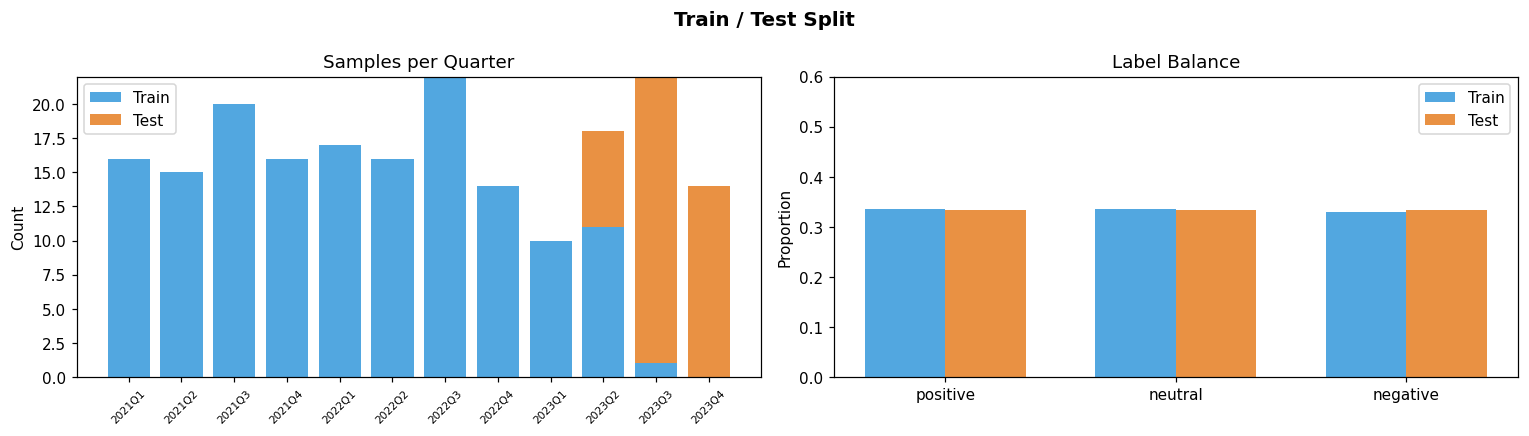

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Train / Test Split", fontsize=13, fontweight="bold")

all_qs = sorted(df["date"].dt.to_period("Q").unique())
train_qc = train_df["date"].dt.to_period("Q").value_counts()
test_qc = test_df["date"].dt.to_period("Q").value_counts()
tr_vals = [train_qc.get(q, 0) for q in all_qs]
te_vals = [test_qc.get(q, 0) for q in all_qs]
x = range(len(all_qs))

axes[0].bar(x, tr_vals, label="Train", color="#3498db", alpha=0.85)
axes[0].bar(x, te_vals, bottom=tr_vals, label="Test", color="#e67e22", alpha=0.85)
axes[0].set_title("Samples per Quarter")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([str(q) for q in all_qs], rotation=45, fontsize=7)
axes[0].legend()
axes[0].set_ylabel("Count")

LABELS_ORDER = ["positive", "neutral", "negative"]
tr_p = [
    train_df["sentiment_label"].value_counts(normalize=True).get(l, 0)
    for l in LABELS_ORDER
]
te_p = [
    test_df["sentiment_label"].value_counts(normalize=True).get(l, 0)
    for l in LABELS_ORDER
]
bx = np.arange(3)
w = 0.35
axes[1].bar(bx - w / 2, tr_p, w, label="Train", color="#3498db", alpha=0.85)
axes[1].bar(bx + w / 2, te_p, w, label="Test", color="#e67e22", alpha=0.85)
axes[1].set_xticks(bx)
axes[1].set_xticklabels(LABELS_ORDER)
axes[1].set_title("Label Balance")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. FinBERT Fine-Tuning

We load `ProsusAI/finbert` (already pre-trained on financial text) and fine-tune its
classification head on our training sentences.


In [ ]:
MODEL_NAME = "ProsusAI/finbert"
LABEL2ID = {"positive": 0, "neutral": 1, "negative": 2}
ID2LABEL = {0: "positive", 1: "neutral", 2: "negative"}
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5

print(f"Loading tokeniser from {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def encode(examples):
    return tokenizer(
        examples["processed_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )


def to_hf_dataset(split_df):
    tmp = split_df[["processed_text", "sentiment_label"]].copy()
    tmp["label"] = tmp["sentiment_label"].map(LABEL2ID)
    ds = HFDataset.from_pandas(tmp[["processed_text", "label"]])
    return ds.map(encode, batched=True, remove_columns=["processed_text"])


print("Tokenising...")
train_ds = to_hf_dataset(train_df)
test_ds = to_hf_dataset(test_df)
print(f"train_ds: {train_ds}")
print(f"test_ds : {test_ds}")


Loading tokeniser from ProsusAI/finbert ...


Tokenising...


Map: 100%|██████████| 42/42 [00:00<00:00, 9769.34 examples/s]

train_ds: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 158
})
test_ds : Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 42
})


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "precision_wt": precision_score(
            labels, preds, average="weighted", zero_division=0
        ),
        "recall_wt": recall_score(labels, preds, average="weighted", zero_division=0),
    }


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

training_args = TrainingArguments(
    output_dir="./finbert_ckpt",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=10,
    seed=SEED,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer),
)

print("Fine-tuning FinBERT...")
train_result = trainer.train()
print(f"Training loss: {train_result.training_loss:.4f}")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54446.86it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning FinBERT...


Epoch,Training Loss,Validation Loss,F1 Weighted,F1 Macro,Precision Wt,Recall Wt
1,1.559125,0.797295,0.714955,0.714955,0.716972,0.714286
2,0.508048,0.455448,0.805372,0.805372,0.806548,0.809524
3,0.325239,0.358439,0.880373,0.880373,0.889894,0.880952


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training loss: 0.7975


In [ ]:
LABELS_ORDER = ["positive", "neutral", "negative"]

pred_out = trainer.predict(test_ds)
y_pred_ids = np.argmax(pred_out.predictions, axis=-1)
y_true_ids = pred_out.label_ids
y_pred = [ID2LABEL[i] for i in y_pred_ids]
y_true = [ID2LABEL[i] for i in y_true_ids]

fb_prec_mac = precision_score(
    y_true, y_pred, average="macro", labels=LABELS_ORDER, zero_division=0
)
fb_rec_mac = recall_score(
    y_true, y_pred, average="macro", labels=LABELS_ORDER, zero_division=0
)
fb_f1_mac = f1_score(
    y_true, y_pred, average="macro", labels=LABELS_ORDER, zero_division=0
)
fb_prec_wt = precision_score(
    y_true, y_pred, average="weighted", labels=LABELS_ORDER, zero_division=0
)
fb_rec_wt = recall_score(
    y_true, y_pred, average="weighted", labels=LABELS_ORDER, zero_division=0
)
fb_f1_wt = f1_score(
    y_true, y_pred, average="weighted", labels=LABELS_ORDER, zero_division=0
)

print("=" * 55)
print("FinBERT Fine-Tuned  —  Evaluation Results")
print("=" * 55)
print(f"  Macro  Precision : {fb_prec_mac:.4f}")
print(f"  Macro  Recall    : {fb_rec_mac:.4f}")
print(f"  Macro  F1        : {fb_f1_mac:.4f}")
print(f"  Wtd.   Precision : {fb_prec_wt:.4f}")
print(f"  Wtd.   Recall    : {fb_rec_wt:.4f}")
print(f"  Wtd.   F1        : {fb_f1_wt:.4f}")
print()
print(classification_report(y_true, y_pred, labels=LABELS_ORDER, digits=4))


FinBERT Fine-Tuned  —  Evaluation Results
  Macro  Precision : 0.8899
  Macro  Recall    : 0.8810
  Macro  F1        : 0.8804
  Wtd.   Precision : 0.8899
  Wtd.   Recall    : 0.8810
  Wtd.   F1        : 0.8804

              precision    recall  f1-score   support

    positive     1.0000    0.8571    0.9231        14
     neutral     0.8235    1.0000    0.9032        14
    negative     0.8462    0.7857    0.8148        14

    accuracy                         0.8810        42
   macro avg     0.8899    0.8810    0.8804        42
weighted avg     0.8899    0.8810    0.8804        42



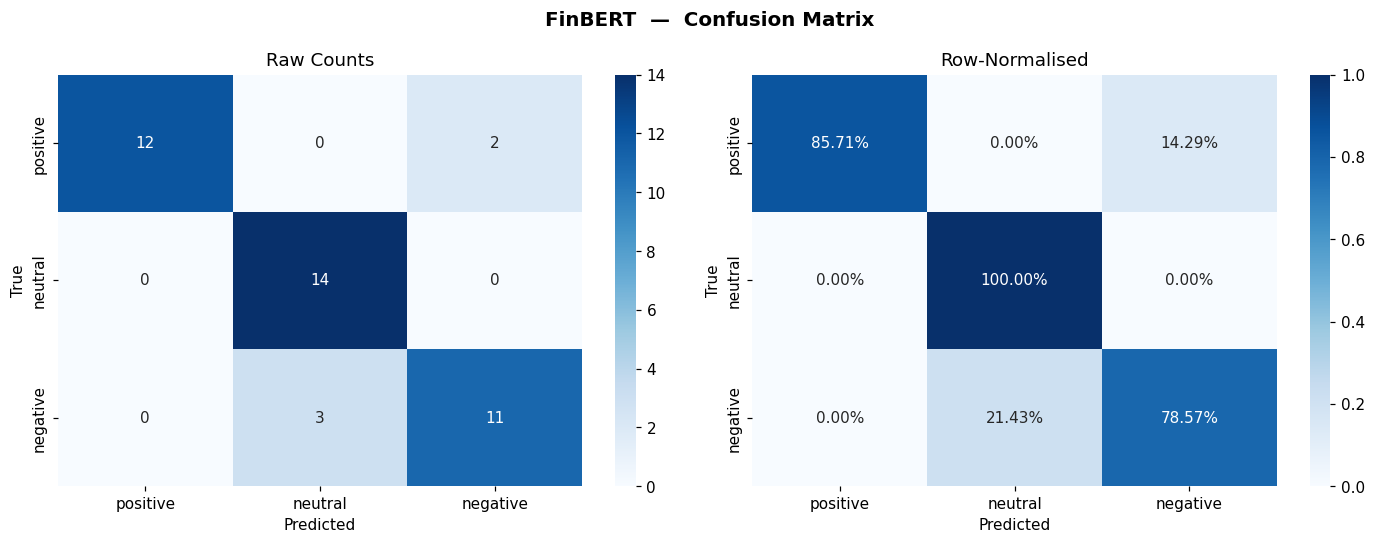

In [ ]:
cm_fb = confusion_matrix(y_true, y_pred, labels=LABELS_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("FinBERT  —  Confusion Matrix", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_fb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS_ORDER,
    yticklabels=LABELS_ORDER,
    ax=axes[0],
)
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_fb_n = cm_fb.astype(float) / (cm_fb.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(
    cm_fb_n,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=LABELS_ORDER,
    yticklabels=LABELS_ORDER,
    ax=axes[1],
)
axes[1].set_title("Row-Normalised")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


## 4. Baseline: Loughran-McDonald Dictionary + Linear SVM

Features: TF-IDF (unigrams + bigrams, top 5 000) concatenated with 6 LM lexicon counts
(positive words, negative words, difference, and their normalised versions).


LM Dict + SVM Baseline  —  Evaluation Results
  Macro  Precision : 0.9299
  Macro  Recall    : 0.9286
  Macro  F1        : 0.9285
  Wtd.   Precision : 0.9299
  Wtd.   Recall    : 0.9286
  Wtd.   F1        : 0.9285

              precision    recall  f1-score   support

    positive     0.9231    0.8571    0.8889        14
     neutral     0.8667    0.9286    0.8966        14
    negative     1.0000    1.0000    1.0000        14

    accuracy                         0.9286        42
   macro avg     0.9299    0.9286    0.9285        42
weighted avg     0.9299    0.9286    0.9285        42



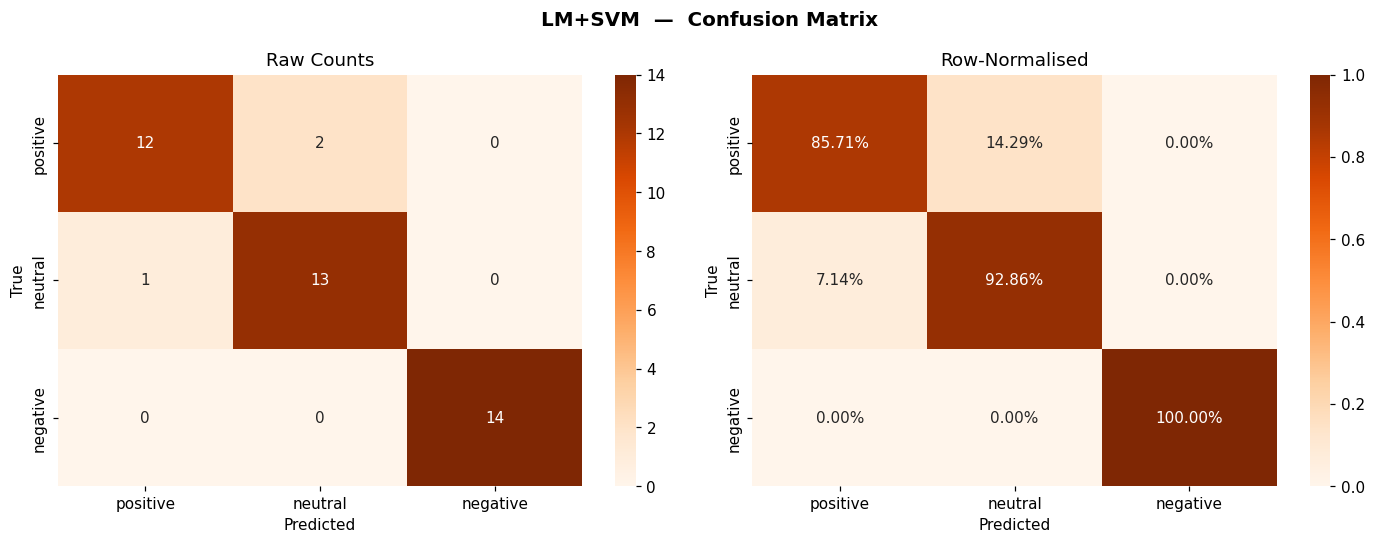

In [ ]:
LM_POSITIVE = {
    "achieve",
    "achievement",
    "advantage",
    "benefit",
    "best",
    "better",
    "boost",
    "confident",
    "deliver",
    "effective",
    "efficiency",
    "enhance",
    "exceed",
    "excellent",
    "exceptional",
    "expand",
    "favorable",
    "gain",
    "good",
    "grew",
    "growth",
    "high",
    "higher",
    "improve",
    "improved",
    "improvement",
    "increase",
    "increased",
    "innovative",
    "leading",
    "maximize",
    "opportunity",
    "outperform",
    "positive",
    "profit",
    "profitability",
    "profitable",
    "progress",
    "record",
    "return",
    "revenue",
    "rising",
    "strong",
    "stronger",
    "success",
    "successful",
    "superior",
    "surpass",
}

LM_NEGATIVE = {
    "adverse",
    "against",
    "below",
    "burden",
    "challenge",
    "challenging",
    "charge",
    "charges",
    "costly",
    "decline",
    "declined",
    "declining",
    "decrease",
    "decreased",
    "deficit",
    "deteriorate",
    "difficulties",
    "difficult",
    "disruption",
    "downturn",
    "drop",
    "failed",
    "failure",
    "fall",
    "headwinds",
    "impairment",
    "impair",
    "inadequate",
    "inflation",
    "inflationary",
    "investigation",
    "issue",
    "litigation",
    "loss",
    "losses",
    "lower",
    "negative",
    "penalty",
    "poor",
    "pressure",
    "problem",
    "reduce",
    "reduced",
    "restructuring",
    "risk",
    "risks",
    "shortage",
    "slow",
    "slowdown",
    "uncertain",
    "uncertainty",
    "unfavorable",
    "weak",
    "weakness",
}


def lm_features(texts):
    rows = []
    for txt in texts:
        words = set(txt.lower().split())
        n = max(len(txt.split()), 1)
        pos = len(words & LM_POSITIVE)
        neg = len(words & LM_NEGATIVE)
        rows.append([pos, neg, pos - neg, pos / n, neg / n, (pos - neg) / n])
    return np.array(rows, dtype=float)


X_tr_txt = train_df["processed_text"].tolist()
X_te_txt = test_df["processed_text"].tolist()
y_train = train_df["sentiment_label"].tolist()
y_test = test_df["sentiment_label"].tolist()

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
X_tr_comb = hstack([tfidf.fit_transform(X_tr_txt), csr_matrix(lm_features(X_tr_txt))])
X_te_comb = hstack([tfidf.transform(X_te_txt), csr_matrix(lm_features(X_te_txt))])

svm = LinearSVC(random_state=SEED, max_iter=5000, C=1.0)
svm.fit(X_tr_comb, y_train)
y_svm = svm.predict(X_te_comb)

svm_prec_mac = precision_score(
    y_test, y_svm, average="macro", labels=LABELS_ORDER, zero_division=0
)
svm_rec_mac = recall_score(
    y_test, y_svm, average="macro", labels=LABELS_ORDER, zero_division=0
)
svm_f1_mac = f1_score(
    y_test, y_svm, average="macro", labels=LABELS_ORDER, zero_division=0
)
svm_prec_wt = precision_score(
    y_test, y_svm, average="weighted", labels=LABELS_ORDER, zero_division=0
)
svm_rec_wt = recall_score(
    y_test, y_svm, average="weighted", labels=LABELS_ORDER, zero_division=0
)
svm_f1_wt = f1_score(
    y_test, y_svm, average="weighted", labels=LABELS_ORDER, zero_division=0
)

print("=" * 55)
print("LM Dict + SVM Baseline  —  Evaluation Results")
print("=" * 55)
print(f"  Macro  Precision : {svm_prec_mac:.4f}")
print(f"  Macro  Recall    : {svm_rec_mac:.4f}")
print(f"  Macro  F1        : {svm_f1_mac:.4f}")
print(f"  Wtd.   Precision : {svm_prec_wt:.4f}")
print(f"  Wtd.   Recall    : {svm_rec_wt:.4f}")
print(f"  Wtd.   F1        : {svm_f1_wt:.4f}")
print()
print(classification_report(y_test, y_svm, labels=LABELS_ORDER, digits=4))

cm_svm = confusion_matrix(y_test, y_svm, labels=LABELS_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("LM+SVM  —  Confusion Matrix", fontsize=13, fontweight="bold")
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=LABELS_ORDER,
    yticklabels=LABELS_ORDER,
    ax=axes[0],
)
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
cm_svm_n = cm_svm.astype(float) / (cm_svm.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(
    cm_svm_n,
    annot=True,
    fmt=".2%",
    cmap="Oranges",
    xticklabels=LABELS_ORDER,
    yticklabels=LABELS_ORDER,
    ax=axes[1],
)
axes[1].set_title("Row-Normalised")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()


## 5. Model Comparison


Model Comparison Summary
                      Precision (Macro)  Recall (Macro)  F1 (Macro)  Precision (Weighted)  Recall (Weighted)  F1 (Weighted)
Model                                                                                                                      
LM+SVM (Baseline)                0.9299          0.9286      0.9285                0.9299             0.9286         0.9285
FinBERT (Fine-tuned)             0.8899          0.8810      0.8804                0.8899             0.8810         0.8804


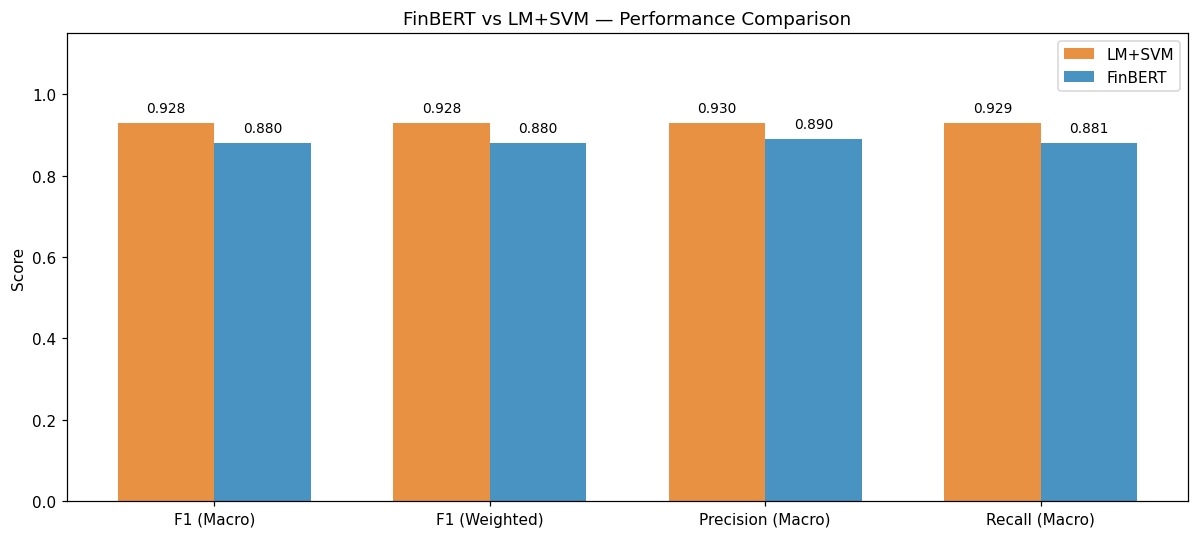

In [ ]:
cmp = pd.DataFrame(
    {
        "Model": ["LM+SVM (Baseline)", "FinBERT (Fine-tuned)"],
        "Precision (Macro)": [svm_prec_mac, fb_prec_mac],
        "Recall (Macro)": [svm_rec_mac, fb_rec_mac],
        "F1 (Macro)": [svm_f1_mac, fb_f1_mac],
        "Precision (Weighted)": [svm_prec_wt, fb_prec_wt],
        "Recall (Weighted)": [svm_rec_wt, fb_rec_wt],
        "F1 (Weighted)": [svm_f1_wt, fb_f1_wt],
    }
).set_index("Model")

print("Model Comparison Summary")
print("=" * 70)
print(cmp.to_string(float_format="{:.4f}".format))

metrics_show = ["F1 (Macro)", "F1 (Weighted)", "Precision (Macro)", "Recall (Macro)"]
bx = np.arange(len(metrics_show))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(
    bx - w / 2,
    [cmp.loc["LM+SVM (Baseline)", m] for m in metrics_show],
    w,
    label="LM+SVM",
    color="#e67e22",
    alpha=0.85,
)
b2 = ax.bar(
    bx + w / 2,
    [cmp.loc["FinBERT (Fine-tuned)", m] for m in metrics_show],
    w,
    label="FinBERT",
    color="#2980b9",
    alpha=0.85,
)
ax.set_xticks(bx)
ax.set_xticklabels(metrics_show)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("FinBERT vs LM+SVM — Performance Comparison")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()
